Here I want to implement a ARIMA model that will be used to prdict the next return or in serie with a ML model to try to validate the result and give the model more strenght. Or it could become a new feature to a more complex model <-- this last seems tyo be the best possibility.

ARIMA(p,d,q):

AR --> AutoRegressive, the p parameter decied how many days in the past the today return is correlated to;

I --> Integrated, the d value decide how many differentiation the serie need to become stationary, in a market price series environment for example d = 0 is already fine, beacuse we are now dealing with return and no more with prices that are not stationary, so a model that takes in returns will be ARIMA(p,0,q);

MA --> MovingAverage, the parameter q implement how many past error have to be used in the final prediction

In [21]:
import yfinance as yf
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

tickers = ['NVDA', 'GOOGL', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'TSM', 'AVGO', 'META', 'TSLA', 'SMCI']


In [11]:
def load_stock(stock='NVDA',start_date='2025-12-01',end_date='2026-01-01'):
    df = yf.download(stock, start=start_date, end=end_date, interval='1d')

    if isinstance(df.columns, pd.MultiIndex):
        lvl0 = df.columns.get_level_values(0)
        lvl1 = df.columns.get_level_values(1)

        if 'Close' in lvl0:
            df.columns = lvl0
        elif 'Close' in lvl1:
            df.columns = lvl1

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=['Close']).copy()
    return df
    
data = load_stock(stock='ACN')

[*********************100%***********************]  1 of 1 completed


In [12]:
# writing of the model, no libraries, less robust

# AR(1)
# yt = c + phi*y_t-1 + eps_t

data['y'] = data['Close'].pct_change()

dataar1 = data.copy()
dataar1['y_lag_1'] = dataar1['y'].shift(1)
dataar1 = dataar1.dropna()

c = 0.01
phi = 0.8

dataar1['y_pred'] = c + phi*dataar1['y_lag_1'] 
dataar1[['y','y_lag_1','y_pred']].head(5)

# now we try to find c and phi by means of linear regression

model = LinearRegression()
model.fit(dataar1[['y_lag_1']],dataar1['y'])
c = model.intercept_
phi = model.coef_[0]

dataar1['y_pred_AR1'] = c + phi*dataar1['y_lag_1'] 
print(dataar1[['y','y_pred_AR1']].head(5))
dataar1['diff'] = abs(dataar1['y']-dataar1['y_pred_AR1'])
print(dataar1['diff'].mean())
print(mean_squared_error(dataar1['y'],dataar1['y_pred_AR1']))

# AR(p)

dataar5 = data.copy()

p = 5

for i in range(1,p+1):
    dataar5[f'y_lag_{i}'] = dataar5['y'].shift(i)

dataar5 = dataar5.dropna().copy()

features = [f'y_lag_{i}' for i in range(1,p+1)]
model = LinearRegression()
model.fit(dataar5[features],dataar5['y'])

c = model.intercept_
phis = model.coef_

dataar5['y_pred_AR5'] = c
for i in range(1,p+1):
    dataar5['y_pred_AR5'] += phis[i-1] * dataar5[f'y_lag_{i}']

print(dataar5[['y','y_pred_AR5']].head(5))
dataar5['diff'] = abs(dataar5['y']-dataar5['y_pred_AR5'])
print(dataar5['diff'].mean())
print(mean_squared_error(dataar5['y'],dataar5['y_pred_AR5']))

Price              y  y_pred_AR1
Date                            
2025-12-03  0.045322    0.000649
2025-12-04 -0.012864   -0.001558
2025-12-05 -0.010210    0.002534
2025-12-08 -0.000338    0.002347
2025-12-09  0.011370    0.001653
0.008804021971905523
0.0001603406713563614
Price              y  y_pred_AR5
Date                            
2025-12-09  0.011370    0.011160
2025-12-10  0.009980    0.005130
2025-12-11 -0.006796   -0.009983
2025-12-12  0.004401    0.001315
2025-12-15  0.011416   -0.000670
0.004053620490439219
2.9411959461875808e-05


In [9]:
# test out of sample
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def train_ARn(data, p):
    df = data.copy()
    df['y'] = df['Close'].pct_change()

    for i in range(1, p + 1):
        df[f'y_lag_{i}'] = df['y'].shift(i)

    df = df.dropna().copy()

    features = [f'y_lag_{i}' for i in range(1, p + 1)]

    model = LinearRegression()
    model.fit(df[features], df['y'])

    c = model.intercept_
    phis = model.coef_

    df[f'y_pred_train_AR{p}'] = c
    for i in range(1, p + 1):
        df[f'y_pred_train_AR{p}'] += phis[i - 1] * df[f'y_lag_{i}']

    return df

def MSE_ARn(data, p, c, phis):
    df = data.copy()
    df['y'] = df['Close'].pct_change()

    for i in range(1, p + 1):
        df[f'y_lag_{i}'] = df['y'].shift(i)

    df[f'y_pred_AR{p}'] = c
    for i in range(1, p + 1):
        df[f'y_pred_AR{p}'] += phis[i - 1] * df[f'y_lag_{i}']

    df = df.dropna().copy()

    mse = mean_squared_error(df['y'], df[f'y_pred_AR{p}'])
    # print(f"AR({p}) MSE = {mse}")

    return mse

data = load_stock('NVDA', start_date='2025-01-01', end_date='2026-03-01')

split = int(len(data) * 0.7)
train = data.iloc[:split].copy()
test = data.iloc[split:].copy()

res = []
for n in range(1, 50):
    c, phis = train_ARn(train, n)
    res.append(MSE_ARn(test, n, c, phis))

dic = {'MSE':res}
res_df = pd.DataFrame(dic)


[*********************100%***********************]  1 of 1 completed


ValueError: too many values to unpack (expected 2)

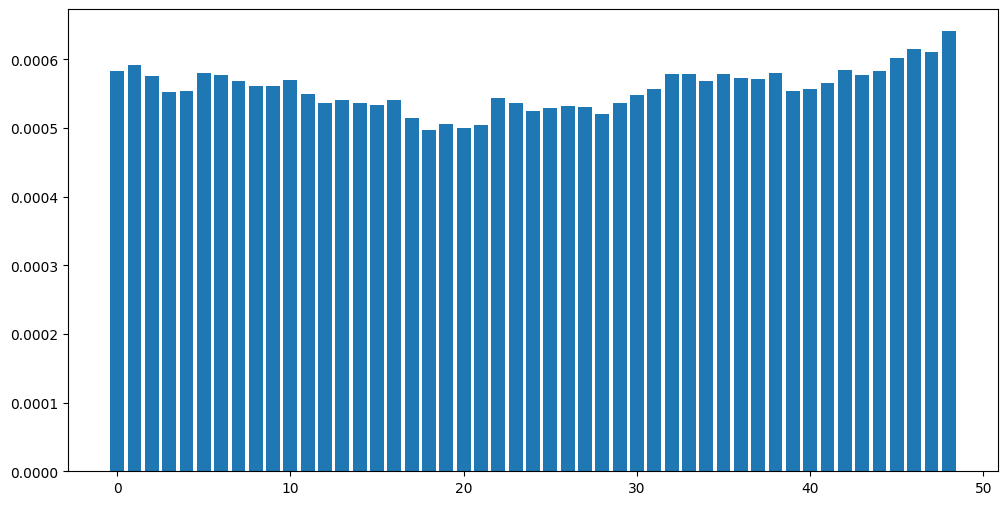

         MSE
18  0.000496
20  0.000500
21  0.000505
19  0.000506
17  0.000514
28  0.000520
24  0.000525
25  0.000530
27  0.000531
26  0.000532


In [ ]:
plt.figure(figsize=(12,6))
plt.bar(res_df.index,res_df['MSE'])
plt.show()

print(res_df.sort_values('MSE')[0:10])

In [24]:
# MA, lag of residuals

def train_MAn(data, q, p):
    data = data.copy()

    df = train_ARn(data, p)

    df['resid'] = df['y'] - df[f'y_pred_train_AR{p}']
    
    for j in range(1,q+1):
        df[f'resid_lag_{j}'] = df['resid'].shift(j)

    df = df.dropna().copy()

    final_features = ([f'y_lag_{i}' for i in range(1,p+1)] + [f'resid_lag_{k}' for k in range(1,q+1)])

    model_final = LinearRegression()
    model_final.fit(df[final_features],df['y'])

    c = model_final.intercept_
    phis = model_final.coef_

    return c,phis,final_features

def MSE_ARIMAn(data, p, q, c, phis, final_features):
    df = data.copy()
    df['y'] = df['Close'].pct_change()

    for i in range(1, p + 1):
        df[f'y_lag_{i}'] = df['y'].shift(i)

    df = df.dropna().copy()

    df[f'y_pred_ar_test'] = c
    for i in range(1,p+1):
        df['y_pred_ar_test'] += phis[i-1] * df[f'y_lag_{i}']

    df['resid_test'] = df['y'] - df[f'y_pred_ar_test']

    for j in range(1,q+1):
        df[f'resid_lag_{j}'] = df['resid_test'].shift(j)

    df = df.dropna().copy()

    df['y_pred_ARIMA'] = c
    for ind,col in enumerate(final_features):
        df['y_pred_ARIMA'] += phis[ind] * df[col]

    mse = mean_squared_error(df['y'], df['y_pred_ARIMA'])
    # print(f"AR({p}) MSE = {mse}")

    return mse

final = []
for stock in tickers:
    data = load_stock(stock, start_date='2025-01-01', end_date='2026-03-01')

    split = int(len(data) * 0.7)
    train = data.iloc[:split].copy()
    test = data.iloc[split:].copy()

    for p in range(1, 10):
        for q in range(1,10):
            c, phis, final_features = train_MAn(train, q, p)
            final.append({
                'stock': stock,
                'mse': MSE_ARIMAn(test, p, q, c, phis, final_features),
                'p': p,
                'q': q
                })

final_df = pd.DataFrame(final)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


using a group by we find the best combination for each stock and use the best combination overall now as the input for a feature col in the ML model.

In [39]:
best_models = final_df.iloc[final_df.groupby('stock')['mse'].idxmin()].reset_index(drop=True)

In [41]:
p_mean = best_models['p'].mean()
q_mean = best_models['q'].mean()
print(p_mean,q_mean)

4.090909090909091 1.1818181818181819
